In [400]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
import numpy as np
import cv2
import os
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt

###Reloading NN

In [401]:
class colorize(nn.Module):
    def __init__(self):
        super().__init__()

        # import resnet
        resnet = models.resnet18(weights="IMAGENET1K_V1")

        # modify layer so that it takes 1 input(lightness) instead of 3 rgb input
        old_conv1 = resnet.conv1
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

        # copy the weights of the old layer over to the new layer, use mean to average the weight across 3 channels into 1 greyscale channel
        resnet.conv1.weight.data = old_conv1.weight.data.mean(dim=1, keepdim=True)

        # remove classification head and average pulling, not needed in this use case, we only need the feature extraction

        self.encoder = nn.Sequential(*list(resnet.children())[:-2])
        # output dim = (batch_size, 512, H/32, W/32)

        # need to upsample back to (batch_size, 2, H, W)
        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(512, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Conv2d(32, 2, kernel_size=3, padding=1),
            nn.Sigmoid()
        )
    # model pipeline
    def forward(self, L):
        features = self.encoder(L)
        ab = self.decoder(features)
        ab = F.interpolate(ab, size=(224, 224), mode='bilinear', align_corners=False)
        return ab



###Conversion function from RGB to normalized LAB
We are using the same functions as the model uses during training

In [402]:
def rgb_to_lab(img):
    img_np = np.array(img)
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB).astype(np.float32)

    # normalize
    L = lab[:,:,0] / 255
    ab = lab[:,:,1:] / 255
    # format for pytorch
    L_tensor = torch.tensor(L).unsqueeze(0).float()  # [1, H, W]
    ab_tensor = torch.tensor(ab).permute(2, 0, 1).float()  # [2, H, W]
    return  (L_tensor, ab_tensor)

def lab_to_rgb(L_tensor, ab_tensor):

    if L_tensor.dim() == 4:        # ensures batch dimension
        L_tensor = L_tensor[0]
    if ab_tensor.dim() == 4:
        ab_tensor = ab_tensor[0]

    L = L_tensor.squeeze(0).cpu().numpy()
    ab = ab_tensor.permute(1, 2, 0).cpu().numpy()

    L = L * 255
    ab = ab * 255

    a = ab[:, :, 0]
    b = ab[:, :, 1]

    lab_image = np.stack([L, a, b], axis=2).astype(np.uint8)
    rgb_image = cv2.cvtColor(lab_image, cv2.COLOR_LAB2RGB)

    return rgb_image

### Import Training Data
#### Using tiny imagenet dataset

In [403]:
if not (os.path.exists("tiny-imagenet-200.zip") or os.path.exists("tiny-imagenet-200")):
    !wget http://cs231n.stanford.edu/tiny-imagenet-200.zip
    !unzip -q tiny-imagenet-200.zip
else:
    print("tiny-imagenet-200 already present — skipping download.")

tiny-imagenet-200 already present — skipping download.


###Colorization
We feed the L portion of an image to the model, then use the predicted ab and the L to reform an RGB image to display. To minimize loss to the actual Lab to RGB conversion, the original image was also converted to lab and then reverted to RGB.

Random image path: ./tiny-imagenet-200/test/images/test_5747.JPEG
L tensor shape: torch.Size([1, 224, 224])
ab tensor shape: torch.Size([2, 224, 224])
Drive already mounted — skipping.


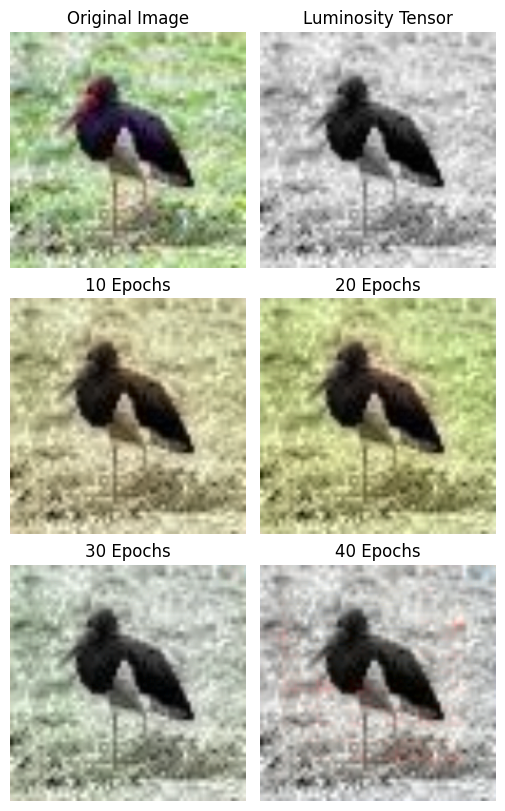

In [404]:
my_transforms = T.Compose([
    T.Resize((224,224)),
    T.Lambda(rgb_to_lab)
])

image_data = ImageFolder('./tiny-imagenet-200/test', transform=my_transforms)

import random
from PIL import Image
import os

# Pick random image path from dataset
rand_path, _ = random.choice(image_data.samples)
print("Random image path:", rand_path)

# Load original RGB image
orig_img = Image.open(rand_path).convert("RGB")

# Apply rgb_to_lab transform
L_tensor, ab_tensor = my_transforms(orig_img)

print("L tensor shape:", L_tensor.shape)
print("ab tensor shape:", ab_tensor.shape)

reconstructed_image = lab_to_rgb(L_tensor,ab_tensor)


device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")

from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted — skipping.")

L_tensor = L_tensor.unsqueeze(0).to(device)

import matplotlib.pyplot as plt

f, axarr = plt.subplots(3,2, layout = 'constrained', figsize=(5,8))

axarr[0,0].set_title("Original Image")
axarr[0,0].imshow(reconstructed_image)
axarr[0,0].axis('off')

axarr[0,1].set_title("Luminosity Tensor")
axarr[0,1].imshow(L_tensor.squeeze().cpu().numpy(), cmap='gray')
axarr[0,1].axis('off')

#Image from 10 epoch model
model = colorize().to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/colorization_model_10.pt', map_location=device))
model.eval()

with torch.no_grad():
    ab_pred = model(L_tensor)

rgb_pred_10 = lab_to_rgb(L_tensor,ab_pred)

axarr[1,0].set_title("10 Epochs")
axarr[1,0].imshow(rgb_pred_10)
axarr[1,0].axis('off')

#Image from 20 epoch model
model = colorize().to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/colorization_model_20.pt', map_location=device))
model.eval()

with torch.no_grad():
    ab_pred = model(L_tensor)

rgb_pred_20 = lab_to_rgb(L_tensor,ab_pred)

axarr[1,1].set_title("20 Epochs")
axarr[1,1].imshow(rgb_pred_20)
axarr[1,1].axis('off')

#Image from 30 epoch model
model = colorize().to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/colorization_model_30.pt', map_location=device))
model.eval()

with torch.no_grad():
    ab_pred = model(L_tensor)

rgb_pred_30 = lab_to_rgb(L_tensor,ab_pred)

axarr[2,0].set_title("30 Epochs")
axarr[2,0].imshow(rgb_pred_30)
axarr[2,0].axis('off')

#Image from 40 epoch model
model = colorize().to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/colorization_model_40.pt', map_location=device))
model.eval()

with torch.no_grad():
    ab_pred = model(L_tensor)

rgb_pred_40 = lab_to_rgb(L_tensor,ab_pred)

axarr[2,1].set_title("40 Epochs")
axarr[2,1].imshow(rgb_pred_40)
axarr[2,1].axis('off')

plt.show()